The purpose of this notebook is to generate the plots of the power spectrum figure we will use in the supplement.

In [2]:
from hydra import compose, initialize
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pathlib import Path
from astropy.timeseries import LombScargle
from methane_noise_forcing import io
from methane_noise_forcing import detrend_obs, calculate_mean_and_ci
from methane_noise_forcing.naming import (
    generate_noise_realization_name,
    generate_firn_smoothing_name,
)
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant,
)
from methane_noise_forcing.core import sample_ensemble_series

plt.rcParams.update(matplotlib_rcparams)

In [3]:
def load_cfg_and_data(site_name):
    if site_name == "wdc05a" or site_name == "wdc06a":
        filter_name = "wais"
    else:
        filter_name = site_name

    with initialize(version_base=None, config_path="../../../configs"):
        cfg = compose(
            config_name="config",
            overrides=[
                f"+noise=white_noise_ar1",
                f"+firn_kernel=firn_model_{filter_name}",
                f"+sampling={site_name}",
            ],
        )

    ## obs and detrending
    data_obs = io.load_observational_data(site_name, **cfg.io[site_name].input)
    # detrend data
    data_obs_detrended = detrend_obs(site_name, data_obs)
    # convert to dataset with 'ch4' and 'ch4_detrended'
    data_obs = xr.Dataset(
        {
            "ch4": (["time"], data_obs.ch4),
            "ch4_detrended": (["time"], data_obs_detrended.ch4),
        },
        coords={"time": data_obs.gas_age},
    )
    # invert time axis
    data_obs = data_obs.isel(time=slice(None, None, -1))

    ## power spectrum
    psd_obs = xr.open_dataset(cfg.io[site_name].power_spectra_path)
    return cfg, data_obs, psd_obs

def calculate_psd(da, time):
    frequencies, power_spectrum = LombScargle(time.values, da.values).autopower(
        normalization="psd",
        samples_per_peak=1,
    )
    return frequencies, power_spectrum

In [4]:
site_names = ["wdc06a", "wdc05a", "gisp2", "neem"]
psd_obs_all = {}
frequencies_obs_all = {}

for site_name in site_names:
    cfg, data_obs, psd_obs = load_cfg_and_data(site_name)
    var_obs = np.var(data_obs["ch4_detrended"], ddof=1)
    ## calculate psd of obs
    data_obs_normalized = data_obs["ch4_detrended"] * np.sqrt(1/var_obs)
    frequencies_obs, psd_obs = calculate_psd(
        data_obs_normalized,
        data_obs_normalized.time
    )
    frequencies_obs_all[site_name] = frequencies_obs
    psd_obs_all[site_name] = psd_obs

2026-01-27 16:42:34,938 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2026-01-27 16:42:34,955 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 2
2026-01-27 16:42:35,516 - methane_noise_forcing.io - INFO - Loading WDC05A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc05a.csv
2026-01-27 16:42:35,521 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 1
2026-01-27 16:42:35,602 - methane_noise_forcing.io - INFO - Loading GISP2 data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_gisp2.csv
2026-01-27 16:42:35,605 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 1
2026-01-27 16:42:35,678 - methane_noise_forcing.io - INFO - Loading NEEM data from /home/disk/p/emei/repos/methane_noise

In [4]:
## sweep obs and psd over all sites
psd_noise_all = {}
psd_noise_sampled_all = {}
psd_obs_all = {}
frequencies_obs_all = {}
data_obs_all = {}

site_names = ["wdc06a", "wdc05a", "gisp2", "neem"]
for site_name in site_names:
    cfg, data_obs, psd_obs = load_cfg_and_data(site_name)


    ## resolve paths
    noise_name = generate_noise_realization_name(cfg)
    firn_name = generate_firn_smoothing_name(cfg)
    input_dir = Path(cfg.paths.noise_realizations_root) / noise_name

    # raw noise
    noise_raw = xr.open_dataset(input_dir / f"{noise_name}.nc")
    # smoothed noise
    noise_smoothed = xr.open_dataset(input_dir / firn_name / f"smoothed_{noise_name}.nc")

    ## sample at same points as obs
    noise_raw_sampled = sample_ensemble_series(
        da=noise_raw["ch4"],
        core_time=data_obs.time,
        core_offset_flag="start",
        series_offset=150,
    )
    noise_smoothed_sampled = sample_ensemble_series(
        da=noise_smoothed["ch4"],
        core_time=data_obs.time,
        core_offset_flag="start",
        series_offset=150,
    )

    # scale such that smoothed and sampled timeseries (obs and simulation) have unit variance on average
    var_obs = np.var(data_obs["ch4_detrended"], ddof=1)
    var_raw = noise_raw["ch4"].var(ddof=1, dim="time")
    var_smoothed = noise_smoothed["ch4"].var(ddof=1, dim="time")
    var_raw_sampled = noise_raw_sampled.var(ddof=1, dim="time")
    var_smoothed_sampled = noise_smoothed_sampled.var(ddof=1, dim="time")
    scaling_ratio_smoothed_sampled = np.sqrt(1 / var_smoothed_sampled.mean())
    noise_raw_scaled = noise_raw["ch4"] * scaling_ratio_smoothed_sampled
    noise_smoothed_scaled = noise_smoothed["ch4"] * scaling_ratio_smoothed_sampled
    noise_raw_sampled *= scaling_ratio_smoothed_sampled
    noise_smoothed_sampled *= scaling_ratio_smoothed_sampled

    ## calculate psd
    psd_raw = []
    psd_smooth = []
    psd_raw_sampled = []
    psd_smooth_sampled = []


    for idx_ens in noise_raw_sampled.ensemble.values:
        # red noise raw
        frequencies, power_spectrum = calculate_psd(
            noise_raw_scaled.sel(ensemble=idx_ens), noise_raw_scaled.time
        )
        psd_raw.append(power_spectrum)

        # red noise smoothed
        frequencies, power_spectrum = calculate_psd(
            noise_smoothed_scaled.sel(ensemble=idx_ens), noise_smoothed_scaled.time
        )
        psd_smooth.append(power_spectrum)

        # red noise raw, sampled
        frequencies_sampled, power_spectrum = calculate_psd(
            noise_raw_sampled.sel(ensemble=idx_ens), noise_raw_sampled.time
        )
        psd_raw_sampled.append(power_spectrum)

        # red noise smoothed
        frequencies_sampled, power_spectrum = calculate_psd(
            noise_smoothed_sampled.sel(ensemble=idx_ens), noise_smoothed_sampled.time
        )
        psd_smooth_sampled.append(power_spectrum)

    # combine into dataset
    psd_noise = xr.Dataset(
        {
            "instantaneous": (["ensemble", "frequency"], np.array(psd_raw)),
            "smoothed": (["ensemble", "frequency"], np.array(psd_smooth)),
        },
        coords={
            "frequency": frequencies,
            "ensemble": noise_raw_sampled.ensemble.values,
        },
    )
    psd_noise_sampled = xr.Dataset(
        {
            "instantaneous_sampled": (["ensemble", "frequency"], np.array(psd_raw_sampled)),
            "sampled": (["ensemble", "frequency"], np.array(psd_smooth_sampled)),
        },
        coords={
            "frequency": frequencies_sampled,
            "ensemble": noise_raw_sampled.ensemble.values,
        },
    )

    ## calculate psd of obs
    data_obs_normalized = data_obs["ch4_detrended"] * np.sqrt(1/var_obs)
    frequencies_obs, psd_obs = calculate_psd(
        data_obs_normalized,
        data_obs_normalized.time
    )

    ## store results
    psd_noise_all[site_name] = psd_noise
    psd_noise_sampled_all[site_name] = psd_noise_sampled
    frequencies_obs_all[site_name] = frequencies_obs
    psd_obs_all[site_name] = psd_obs
    data_obs_all[site_name] = data_obs

2026-01-27 10:19:29,657 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2026-01-27 10:19:29,660 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 2
2026-01-27 10:19:50,681 - methane_noise_forcing.io - INFO - Loading WDC05A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc05a.csv
2026-01-27 10:19:50,686 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 1
2026-01-27 10:20:09,534 - methane_noise_forcing.io - INFO - Loading GISP2 data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_gisp2.csv
2026-01-27 10:20:09,539 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 1
2026-01-27 10:20:29,273 - methane_noise_forcing.io - INFO - Loading NEEM data from /home/disk/p/emei/repos/methane_noise

# timeseries of all sites

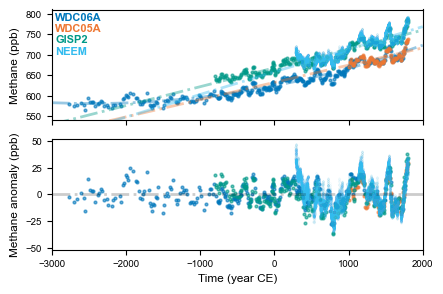

In [5]:
# timeseries parameters
ylim_detrended = (-52, 52)
yticks_detrended = [-50, -25, 0, 25, 50]
ylim = (540, 810)
yticks = [550, 600, 650, 700, 750, 800]
xlim = (-3000, 2000)
time_shading = (800, 1800)

colors_site = {
    "wdc06a": colors_vibrant["blue"],
    "wdc05a": colors_vibrant["orange"],
    "gisp2": colors_vibrant["teal"],
    "neem": colors_vibrant["cyan"]
}
plot_kwargs_non_neem = {
    "marker": "o",
    "markersize": 2,
    "linestyle": "None",
    "alpha":0.6,
}
plot_kwargs_neem = {
    "marker": "o",
    "markersize": 0.05,
    "linestyle": "None",
    "alpha":0.6,
}
plot_kwargs_site = {
    "wdc05a": plot_kwargs_non_neem,
    "wdc06a": plot_kwargs_non_neem,
    "gisp2": plot_kwargs_non_neem,
    "neem": plot_kwargs_neem,
}

fig_width = fig_width_options["two_column_small"]
site_names = ["wdc06a", "wdc05a", "gisp2", "neem"]
fig, axs = plt.subplots(2, 1, figsize=(fig_width, 3), tight_layout=True, sharex=True)
axs = axs.flatten()

# raw data
for site_name in site_names:
    data_obs = data_obs_all[site_name]

    # fit and plot linear trend
    if site_name == "wdc06a":
        order = 2
    else:
        order = 1
    coeffs = np.polyfit(data_obs["time"], data_obs["ch4"], order)
    # append beginning and end xlim to trend line
    x_trend = [xlim[0]] + data_obs["time"].values.tolist() + [xlim[1]]
    trend = np.polyval(coeffs, x_trend)
    axs[0].plot(
        x_trend,
        trend,
        color=colors_site[site_name],
        linestyle="-.",
        linewidth=2,
        alpha=0.4
    )

    # plot data
    axs[0].plot(
        data_obs.time,
        data_obs.ch4,
        color=colors_site[site_name],
        **plot_kwargs_site[site_name],
    )

## detrended methane
for site_name in site_names:
    data_obs = data_obs_all[site_name]

    # plot detrended data
    axs[1].plot(
        data_obs.time,
        data_obs.ch4_detrended,
        color=colors_site[site_name],
        **plot_kwargs_site[site_name],
    )
axs[1].axhline(0, color="k", linestyle="-.", linewidth=2, alpha=0.2)
    
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
axs[0].set_yticks(yticks)
axs[1].set_ylim(ylim_detrended)
axs[1].set_yticks(yticks_detrended)

axs[0].set_ylabel("Methane (ppb)")
axs[1].set_ylabel("Methane anomaly (ppb)")
axs[1].set_xlabel("Time (year CE)")

# plot legend in top left of first axis
legend_x = 0.01
legend_y_start = 0.97
legend_dy = 0.1
for i, site_name in enumerate(site_names):
    axs[0].text(
        legend_x,
        legend_y_start - i * legend_dy,
        site_name.upper(),
        color=colors_site[site_name],
        transform=axs[0].transAxes,
        fontsize=8,
        fontweight="bold",
        verticalalignment="top",
    )

# save figure in pdf format
name = "timeseries_all_sites"
fig.savefig(
    f"{cfg.paths.figures_dir}/for_publication/supplement/{name}.pdf", bbox_inches="tight", dpi=200
)

# power spectra of all sites

In [6]:
## figure settings
plot_kwargs = dict(
    obs={
        "color": "k",
        "linewidth": 0.5,
        "alpha": 0.25,
    },
    instantaneous={
        "color": colors_vibrant["blue"],
        "linestyle": "--",
    },
    smoothed={
        "color": colors_vibrant["magenta"],
        "linestyle": "--",
    },
    sampled={
        "color": colors_vibrant["orange"],
        "linestyle": "-",
        "linewidth": 2,
    },
)
alpha_fill_between=0.15

def plot_psd(
        ax, 
        frequencies_obs,
        psd_obs, 
        psd_noise, 
        psd_noise_sampled, 
        period_low=4.673, 
        period_high=1000, 
        skip_freq=10,
        x_tick_labels_psd=[1000, 100, 20, 10, 5],
        y_tick_labels_psd=[0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
        ylim=(0.7e-4, 1.6e2),
        xlim_psd = (3.8, 1100),
    ):
    # mask frequencies to plot
    mask = (psd_noise.frequency >= 1 / period_high) & (psd_noise.frequency <= 1 / period_low)
    frequencies_to_plot = psd_noise.frequency[mask]
    mask = (psd_noise_sampled.frequency >= 1 / period_high) & (psd_noise_sampled.frequency <= 1 / period_low)
    frequencies_sampled_to_plot = psd_noise_sampled.frequency[mask]
    mask = (frequencies_obs >= 1 / period_high) & (frequencies_obs <= 1 / period_low)
    frequencies_obs_to_plot = frequencies_obs[mask]
    psd_obs_to_plot = psd_obs[mask]

    # observed psd
    ax.plot(
        1 / frequencies_obs_to_plot,
        psd_obs_to_plot,
        **plot_kwargs["obs"]
    )
    # plot mean for ensemble of psds for instantaneous and smoothed
    for key in ["instantaneous", "smoothed"]:
        ax.plot(
            1 / psd_noise.sel(frequency=frequencies_to_plot).frequency[::skip_freq],
            psd_noise.sel(frequency=frequencies_to_plot)[key].mean(dim="ensemble")[::skip_freq],
            **plot_kwargs[key]
        )
    # plot mean and ci for sampled psds
    mean, ci_low, ci_high = calculate_mean_and_ci(
        psd_noise_sampled.sel(frequency=frequencies_sampled_to_plot)["sampled"]
    )
    ax.plot(
        1 / psd_noise_sampled.sel(frequency=frequencies_sampled_to_plot).frequency[::skip_freq],
        mean[::skip_freq],
        **plot_kwargs["sampled"]
    )
    ax.fill_between(
        1 / psd_noise_sampled.sel(frequency=frequencies_sampled_to_plot).frequency[::skip_freq],
        ci_low[::skip_freq],
        ci_high[::skip_freq],
        color=plot_kwargs["sampled"]["color"],
        alpha=alpha_fill_between,
        edgecolor="none",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("Period (years)")
    ax.set_ylabel("Power (normalized)", labelpad=-1)
    ax.set_xlim(xlim_psd)
    ax.invert_xaxis()

    ax.set_xticks(x_tick_labels_psd)
    ax.set_xticklabels([f"{tick}" for tick in x_tick_labels_psd])

    # # set y-axis ticks to plain numbers
    ax.set_ylim(ylim)
    ax.set_yticks(y_tick_labels_psd)
    ax.set_yticklabels([str(y) for y in y_tick_labels_psd])

Text(0.01, 0.02, 'Pseudo-ice core ensemble mean')

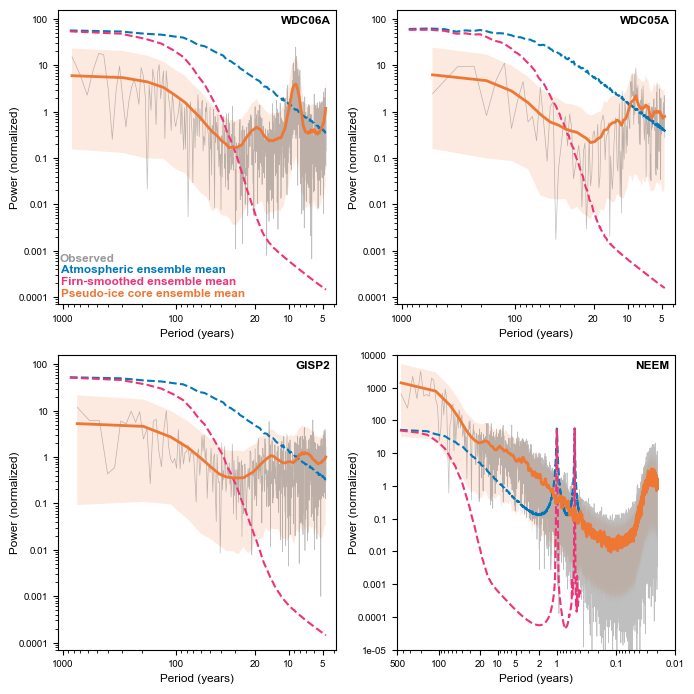

In [ ]:
fig_width = fig_width_options["two_column_large"]
fig, axs = plt.subplots(2, 2, figsize=(fig_width, 7), tight_layout=True)
axs = axs.flatten()
site_names = ["wdc06a", "wdc05a", "gisp2", "neem"]
for i, site_name in enumerate(site_names):
    ax = axs[i]
    skip_freq = 10
    period_high = 1000
    period_low = 4.673
    ylim_psd = (0.7e-4, 1.6e2)
    xlim_psd = (3.8, 1100)
    x_tick_labels_psd = [1000, 100, 20, 10, 5]
    y_tick_labels_psd = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
    if site_name == "neem":
        period_high = 480
        period_low = 2
        x_tick_labels_psd = [500, 100, 20, 10, 5, 2]
        xlim_psd = (1.5, 510)
        y_tick_labels_psd = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
        ylim_psd = (0.00005, 10000)
    elif site_name == "wdc05a":
        skip_freq = 3

    plot_psd(
        ax,
        frequencies_obs_all[site_name],
        psd_obs_all[site_name],
        psd_noise_all[site_name],
        psd_noise_sampled_all[site_name],
        skip_freq=skip_freq,
        period_high=period_high,
        period_low=period_low,
        x_tick_labels_psd=x_tick_labels_psd,
        y_tick_labels_psd=y_tick_labels_psd,
        ylim=ylim_psd,
        xlim_psd=xlim_psd,
    )
    
    # in top right, add site name
    ax.text(
        0.98,
        0.98,
        site_name.upper(),
        ha="right",
        va="top",
        transform=ax.transAxes,
        fontweight="bold",
    )

# for first axis, add legend text
legend_x = 0.01
legend_y_start = 0.02
legend_dy = 0.04
axs[0].text(
    legend_x-0.003, legend_y_start + 3*legend_dy,
    "Observed",
    color=plot_kwargs["obs"]["color"],
    alpha=0.4,
    fontweight="bold",
    ha="left", va="bottom",
    transform=axs[0].transAxes,
)
axs[0].text(
    legend_x, legend_y_start + 2*legend_dy,
    "Atmospheric ensemble mean",
    color=plot_kwargs["instantaneous"]["color"],
    fontweight="bold",
    ha="left", va="bottom",
    transform=axs[0].transAxes,
)
axs[0].text(
    legend_x, legend_y_start + legend_dy,
    "Firn-smoothed ensemble mean",
    color=plot_kwargs["smoothed"]["color"],
    fontweight="bold",
    ha="left", va="bottom",
    transform=axs[0].transAxes,
)
axs[0].text(
    legend_x, legend_y_start,
    "Pseudo-ice core ensemble mean",
    color=plot_kwargs["sampled"]["color"],
    fontweight="bold",
    ha="left", va="bottom",
    transform=axs[0].transAxes,
)

# save figure in pdf format
name = "power_spectra_all_sites"
fig.savefig(
    f"{cfg.paths.figures_dir}/for_publication/supplement/{name}.pdf", bbox_inches="tight", dpi=200
)

# Power spectra at 8- and 12- years

In [28]:
from methane_noise_forcing.noise import (
    simulate_white_noise_ar1,
    calculate_white_noise_ar1_params,
)
from methane_noise_forcing.core import FirnFilter
dt = 1 # time step in years
variance = 300
methane_lifetimes = [8, 10, 12] # sensitivity test with 8-12 year lifetimes
site_name = "wdc06a"
n_years = 5000
n_ens = 1000
noise_raw = {}
noise_smoothed = {}
noise_raw_sampled = {}
noise_smoothed_sampled = {}


for lifetime in methane_lifetimes:
    cfg, data_obs, psd_obs = load_cfg_and_data(site_name)

    # calculate ar1 params
    params = calculate_white_noise_ar1_params(lifetime, dt, variance)
    red_noise, white_noise = simulate_white_noise_ar1(
            phi=params.phi,
            sigma_eps=params.sigma_eps,
            n_steps=int(n_years / dt),
            n_ens=n_ens,
        )
    # create dataarray
    noise_raw[lifetime] = xr.DataArray(
        red_noise[:, :, np.newaxis],
        dims=["ensemble", "time", "lifetime"],
        coords={
            "ensemble": np.arange(n_ens),
            "time": np.arange(0, n_years, dt),
            "lifetime": [lifetime],
        },
    )

    # smooth noise
    with initialize(
        version_base=None, config_path="../../../configs"
    ):  # configs with data paths
        cfg = compose(
            config_name="config",
            overrides=[
                "+noise=white_noise_ar1",
                "++noise.duration_timeseries=4750",
                "+firn_kernel=firn_model_wais",
            ],
        )
    firn_filter = FirnFilter.fit_from_config(
        kernel_type=cfg.firn_kernel.type,
        parameters=cfg.firn_kernel.parameters,
        path_root=cfg.paths.firn_filters_root,
    )
    noise_smoothed_lifetime = []
    for idx_ens in noise_raw[lifetime].ensemble.values:
        smoothed = firn_filter.apply(
            noise_raw[lifetime].sel(ensemble=idx_ens).squeeze("lifetime").values,
            dt_series=dt,
            flip_kernel=True,
        )
        noise_smoothed_lifetime.append(smoothed)
    noise_smoothed_lifetime = np.array(noise_smoothed_lifetime)
    noise_smoothed[lifetime] = xr.DataArray(
        noise_smoothed_lifetime[:, :, np.newaxis],
        dims=["ensemble", "time", "lifetime"],
        coords={
            "ensemble": noise_raw[lifetime].ensemble.values,
            "time": noise_raw[lifetime].time.values,
            "lifetime": [lifetime],
        },
    )

    # sample noise
    noise_raw_sampled[lifetime] = sample_ensemble_series(
        da=noise_raw[lifetime].isel(lifetime=0),
        core_time=data_obs.time,
        core_offset_flag="start",
        series_offset=150,
    ).expand_dims("lifetime").assign_coords(lifetime=[lifetime])
    noise_smoothed_sampled[lifetime] = sample_ensemble_series(
        da=noise_smoothed[lifetime].isel(lifetime=0),
        core_time=data_obs.time,
        core_offset_flag="start",
        series_offset=150,
    ).expand_dims("lifetime").assign_coords(lifetime=[lifetime])

# concatenate along lifetime dimension
noise_raw = xr.concat(list(noise_raw.values()), dim="lifetime")
noise_smoothed = xr.concat(list(noise_smoothed.values()), dim="lifetime")
noise_raw_sampled = xr.concat(list(noise_raw_sampled.values()), dim="lifetime")
noise_smoothed_sampled = xr.concat(list(noise_smoothed_sampled.values()), dim="lifetime")

2026-01-27 11:08:54,541 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2026-01-27 11:08:54,546 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 2
2026-01-27 11:08:56,352 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2026-01-27 11:08:56,356 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 2
2026-01-27 11:08:58,129 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2026-01-27 11:08:58,132 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 2


In [29]:
# calculate psds
psd_noise_lifetimes = {}
psd_noise_sampled_lifetimes = {}
for lifetime in methane_lifetimes:
    # standardize variance to sampled data
    var_raw_sampled = noise_raw_sampled.sel(lifetime=lifetime).var(ddof=1, dim="time")
    var_smoothed_sampled = noise_smoothed_sampled.sel(lifetime=lifetime).var(ddof=1, dim="time")
    scaling_ratio_smoothed_sampled = np.sqrt(1 / var_smoothed_sampled.mean())
    noise_raw_scaled = noise_raw.sel(lifetime=lifetime) * scaling_ratio_smoothed_sampled
    noise_smoothed_scaled = noise_smoothed.sel(lifetime=lifetime) * scaling_ratio_smoothed_sampled
    noise_raw_sampled_scaled = noise_raw_sampled.sel(lifetime=lifetime) * scaling_ratio_smoothed_sampled
    noise_smoothed_sampled_scaled = noise_smoothed_sampled.sel(lifetime=lifetime) * scaling_ratio_smoothed_sampled

    ## calculate psd
    psd_raw = []
    psd_smooth = []
    psd_smooth_sampled = []
    for idx_ens in noise_raw_sampled.ensemble.values:
        # red noise raw
        frequencies, power_spectrum = calculate_psd(
            noise_raw_scaled.sel(ensemble=idx_ens), noise_raw_scaled.time
        )
        psd_raw.append(power_spectrum)

        # red noise smoothed
        frequencies, power_spectrum = calculate_psd(
            noise_smoothed_scaled.sel(ensemble=idx_ens), noise_smoothed_scaled.time
        )
        psd_smooth.append(power_spectrum)

        # red noise smoothed
        frequencies_sampled, power_spectrum = calculate_psd(
            noise_smoothed_sampled_scaled.sel(ensemble=idx_ens), noise_smoothed_sampled_scaled.time
        )
        psd_smooth_sampled.append(power_spectrum)
    # combine into dataset
    psd_noise = xr.Dataset(
        {
            "instantaneous": (["ensemble", "frequency"], np.array(psd_raw)),
            "smoothed": (["ensemble", "frequency"], np.array(psd_smooth)),
        },
        coords={
            "frequency": frequencies,
            "ensemble": noise_raw_sampled.ensemble.values,
        },
    )
    psd_noise_sampled = xr.Dataset(
        {
            "sampled": (["ensemble", "frequency"], np.array(psd_smooth_sampled)),
        },
        coords={
            "frequency": frequencies_sampled,
            "ensemble": noise_raw_sampled.ensemble.values,
        },
    )

    psd_noise_lifetimes[lifetime] = psd_noise
    psd_noise_sampled_lifetimes[lifetime] = psd_noise_sampled

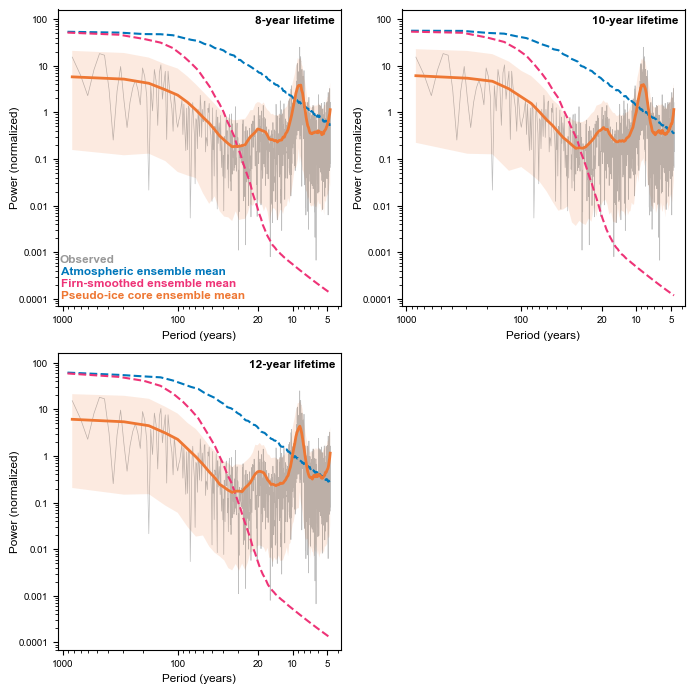

In [31]:
fig_width = fig_width_options["two_column_large"]
fig, axs = plt.subplots(2, 2, figsize=(fig_width, 7), tight_layout=True)
axs = axs.flatten()
timescales_to_plot = methane_lifetimes
for i, lifetime in enumerate(timescales_to_plot):
    ax = axs[i]
    skip_freq = 10
    period_high = 1000
    period_low = 4.673
    ylim_psd = (0.7e-4, 1.6e2)
    x_tick_labels_psd = [1000, 100, 20, 10, 5]
    y_tick_labels_psd = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

    plot_psd(
        ax,
        frequencies_obs_all[site_name],
        psd_obs_all[site_name],
        psd_noise_lifetimes[lifetime],
        psd_noise_sampled_lifetimes[lifetime].sel(ensemble=slice(0, n_ens)).assign_coords(ensemble=np.arange(n_ens)),
        skip_freq=skip_freq,
        period_high=period_high,
        period_low=period_low,
        x_tick_labels_psd=x_tick_labels_psd,
        y_tick_labels_psd=y_tick_labels_psd,
        ylim=ylim_psd,
    )
    
    # in top right, add lifetime
    ax.text(
        0.98,
        0.98,
        f"{lifetime}-year lifetime",
        ha="right",
        va="top",
        transform=ax.transAxes,
        fontweight="bold",
    )
# make last axis blank
axs[3].axis("off")

# for first axis, add legend text
legend_x = 0.01
legend_y_start = 0.02
legend_dy = 0.04
axs[0].text(
    legend_x-0.003, legend_y_start + 3*legend_dy,
    "Observed",
    color=plot_kwargs["obs"]["color"],
    alpha=0.4,
    fontweight="bold",
    ha="left", va="bottom",
    transform=axs[0].transAxes,
)
axs[0].text(
    legend_x, legend_y_start + 2*legend_dy,
    "Atmospheric ensemble mean",
    color=plot_kwargs["instantaneous"]["color"],
    fontweight="bold",
    ha="left", va="bottom",
    transform=axs[0].transAxes,
)
axs[0].text(
    legend_x, legend_y_start + legend_dy,
    "Firn-smoothed ensemble mean",
    color=plot_kwargs["smoothed"]["color"],
    fontweight="bold",
    ha="left", va="bottom",
    transform=axs[0].transAxes,
)
axs[0].text(
    legend_x, legend_y_start,
    "Pseudo-ice core ensemble mean",
    color=plot_kwargs["sampled"]["color"],
    fontweight="bold",
    ha="left", va="bottom",
    transform=axs[0].transAxes,
)

# save figure in pdf format
name = "power_spectra_lifetime"
fig.savefig(
    f"{cfg.paths.figures_dir}/for_publication/supplement/{name}.pdf", bbox_inches="tight", dpi=200
)

# plot smoothing kernel